In [ ]:
!pip install drain3 transformers[torch] accelerate -U
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import shutil
import os
import io
import torch
import json

from torch.utils.data import Dataset
from google.colab import files
from google.colab import drive
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig
from drain3.masking import MaskingInstruction
from sklearn.preprocessing import MultiLabelBinarizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 50.8 MB/s eta 0:00:00
  Created wheel for drain3: filename=drain3-0.9.11-py3-none-any.whl size=23998 sha256=b104e11c34ffec5554cba5cab51eef5c52489094e9613e320d21b355c7db4247
  Stored in directory: /root/.cache/pip/wheels/3f/d1/46/58e1747b3d77c4990f838e1c1f610f5aab1a21889cc9bff5c2
Successfully built drain3
  Attempting uninstall: jsonpickle
    Found existing installation: jsonpickle 4.1.1
    Uninstalling jsonpickle-4.1.1:
      Successfully uninstalled jsonpickle-4.1.1
  Attempting uninstall: cachetools
    Found existing installation: cachetools 6.2.6
    Uninstalling cachetools-6.2.6:
      Successfully uninstalled cachetools-6.2.6
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packag

In [ ]:
# UPLOAD DATA (ansible_teheis_coherent_10k.csv)
print("Please upload your logs CSV file:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

Please upload your logs CSV file:


Saving ansible_thesis_final_v4.csv to ansible_thesis_final_v4.csv


In [ ]:
print(df['fault_category'].value_counts())
print(f"iac categories: {df['iac_category'].value_counts()}")

fault_category
State Mismanagement                           5606
Variable Misreference                         1890
Incorrect Detection/Analysis of User Input    1053
Dependency-related Faults                      625
Incorrect Task Iteration Logic                 424
Typos                                          402
Name: count, dtype: int64
iac categories: iac_category
Idempotency           1250
Service               1250
Documentation         1250
Configuration Data    1250
Conditional           1250
Syntax                1250
Security              1250
Dependency            1250
Name: count, dtype: int64


In [ ]:
# CONFIGURE DRAIN
config = TemplateMinerConfig()
config.profiling_enabled = False

config.masking_instructions = [
    MaskingInstruction(r"\*+", "STARS"),

    # We keep TASK_NAME but removed PLAY_NAME as we filter those lines out
    MaskingInstruction(r"(?<=TASK \[).+?(?=\])", "TASK_NAME"),

    MaskingInstruction(r"\b(?:[A-Za-z0-9_-]+\.)+[A-Za-z]{2,}\b", "HOST"),

]

config.drain_depth = 6
"""
If you find that very different errors are being grouped into the same template, increase sim_th to 0.6 or 0.7
"""
config.drain_sim_th = 0.7
template_miner = TemplateMiner(config=config)

# APPLY TO DATAFRAME
def get_template(log_line):
    """
    Cleans the log by removing PLAY headers and flattening multi-line
    Ansible JSON output into a single atomic string for better token density.
    """
    # 1. Split into lines
    lines = str(log_line).splitlines()

    # 2. Filter out PLAY headers and empty lines, then strip whitespace
    filtered_lines = [
        line.strip() for line in lines
        if not line.strip().startswith("PLAY") and line.strip()
    ]

    # 3. Join into a single-line string (re-flattening)
    flattened_log = " ".join(filtered_lines)

    # 4. Extract template via Drain3
    result = template_miner.add_log_message(flattened_log)
    return result['template_mined']

print("Cleaning logs, removing PLAY headers, and flattening multi-line events...")
df['cleaned_text'] = df['log'].apply(get_template)

# Consolidate labels based on the cleaned templates
df['iac_category'] = df.groupby('cleaned_text')['iac_category'].transform(lambda x: x.mode()[0])
df['fault_category'] = df.groupby('cleaned_text')['fault_category'].transform(lambda x: x.mode()[0])

# VIEW RESULTS
print("\nSuccess! Sample Transformation:")
print("-" * 30)
print(f"Original Log Snippet:\n{df['log'].iloc[0][:150]}...") # Showing first 150 chars
print("-" * 30)
print(f"Cleaned Template:\n{df['cleaned_text'].iloc[0]}")
print("-" * 30)

Cleaning logs, removing PLAY headers, and flattening multi-line events...

Success! Sample Transformation:
------------------------------
Original Log Snippet:
TASK [Install git] *********************************************
failed: [web1.prod] => {"changed": false, "msg": "Unable to locate package git", "rc"...
------------------------------
Cleaned Template:
TASK [<TASK_NAME>] <STARS> failed: [<HOST>] => {"changed": false, "msg": "Unable to locate package git", "rc": 100}
------------------------------


In [ ]:
# Dataframe check
df

,log,iac_category,fault_category,cleaned_text
0,skipping: [app_srv.internal] => (item=None) =>...,Dependency,Dependency-related Fault,skipping: [<HOST>] => (item=None) => condition...
1,changed: [app_srv.internal] => {'msg': 'Mismat...,Documentation,Incorrect Task Iteration Logic,changed: [<HOST>] => {'msg': 'Mismatch between...
2,changed: [db1.example.com] => {'msg': 'Could n...,Service,Dependency-related Fault,changed: [<HOST>] => {'msg': 'Could not find s...
3,ERROR! Syntax error while loading systemd. Aut...,Security,Typo,ERROR! Syntax error while loading systemd. Aut...
4,failed: [node-01.local] => {'msg': 'Failed to ...,Syntax,Variable Misreference,failed: [<HOST>] => {'msg': 'Failed to parse u...
...,...,...,...,...
9995,changed: [monitor.example.com] => {'msg': 'Whe...,Conditional,State Mismanagement,changed: [<HOST>] => {'msg': 'When clause eval...
9996,failed: [lb-ext.net] => {'msg': 'Authenticatio...,Security,Typo,failed: [<HOST>] => {'msg': <*> <*> <*> <*> <*...
9997,fatal: [web1.example.com]: FAILED! => {'msg': ...,Service,Dependency-related Fault,fatal: [<HOST>]: FAILED! => {'msg': <*> <*> <*...
9998,ERROR! Syntax error while loading copy. No pac...,Dependency,Dependency-related Fault,ERROR! Syntax error while loading <*> <*> <*> ...


In [ ]:
# check if distribution is balanced
print(df['iac_category'].value_counts())
print('\n')
print(df['fault_category'].value_counts())

iac_category
Security              1301
Documentation         1274
Idempotency           1269
Configuration Data    1240
Conditional           1239
Syntax                1237
Dependency            1223
Service               1217
Name: count, dtype: int64


fault_category
Dependency-related Fault                      1718
Variable Misreference                         1675
Incorrect Detection/Analysis of User Input    1667
Typo                                          1662
Incorrect Task Iteration Logic                1640
State Mismanagement                           1638
Name: count, dtype: int64


In [ ]:
pair_counts = df.groupby("cleaned_text").agg(
    n_rows=("cleaned_text", "size"),
    n_iac=("iac_category", "nunique"),
    n_fault=("fault_category", "nunique")
).reset_index()

conflict_templates = pair_counts[(pair_counts.n_iac > 1) | (pair_counts.n_fault > 1)]
print(f"Templates with conflicts: {len(conflict_templates)}")
print(conflict_templates.sort_values(["n_iac", "n_fault"], ascending=False).head(20))

Templates with conflicts: 320
                                          cleaned_text  n_rows  n_iac  n_fault
0    ERROR! Syntax error while loading <*> <*> <*> ...     680      7        6
691  skipping: [<HOST>] => (item=None) => condition...     785      7        6
206  changed: [<HOST>] => {'msg': <*> <*> <*> <*> <...      31      7        1
207  changed: [<HOST>] => {'msg': <*> <*> <*> <*> <...      47      7        1
209  changed: [<HOST>] => {'msg': <*> <*> <*> <*> <...      39      7        1
211  changed: [<HOST>] => {'msg': <*> <*> <*> <*> <...      44      7        1
213  changed: [<HOST>] => {'msg': <*> <*> <*> <*> <...      49      7        1
214  changed: [<HOST>] => {'msg': <*> <*> <*> <*> <...      34      7        1
216  changed: [<HOST>] => {'msg': <*> <*> <*> <*> <...      37      7        1
217  changed: [<HOST>] => {'msg': <*> <*> <*> <*> <...      24      7        1
218  changed: [<HOST>] => {'msg': <*> <*> <*> <*> <...      47      7        1
219  changed: [<HOST>]

## DRAIN-less setup

## New Version with new Dataset

In [ ]:
import os
import io
import json
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, BertModel, TrainingArguments, Trainer, EarlyStoppingCallback
from google.colab import files, drive

# 1. UPLOAD TRAINING DATASET
uploaded = files.upload()
train_filename = list(uploaded.keys())[0]
train_df = pd.read_csv(io.BytesIO(uploaded[train_filename]))

# 2. BASIC CHECKS
required_cols = {"log", "iac_category", "fault_category"}
missing = required_cols - set(train_df.columns)
if missing:
    raise ValueError(f"Training file missing columns: {missing}")

# 3. CLEAN LOGS
def clean_log_drainless(log_line):
    lines = str(log_line).splitlines()
    return " ".join([line.strip() for line in lines if line.strip() and not line.strip().startswith("PLAY")])

train_df["drainless_text"] = train_df["log"].apply(clean_log_drainless)

# 4. ENCODE LABELS
iac_encoder = LabelEncoder()
fault_encoder = LabelEncoder()

train_df["iac_id"] = iac_encoder.fit_transform(train_df["iac_category"])
train_df["fault_id"] = fault_encoder.fit_transform(train_df["fault_category"])

iac_categories = iac_encoder.classes_.tolist()
fault_categories = fault_encoder.classes_.tolist()

# 5. TOKENIZE
tokenizer = AutoTokenizer.from_pretrained("huawei-noah/TinyBERT_General_4L_312D")
encodings = tokenizer(
    train_df["drainless_text"].tolist(),
    padding=True,
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

# 6. DATASET
class MultiHeadAnsibleDataset(Dataset):
    def __init__(self, encodings, iac_labels, fault_labels):
        self.encodings = encodings
        self.iac_labels = torch.tensor(iac_labels, dtype=torch.long)
        self.fault_labels = torch.tensor(fault_labels, dtype=torch.long)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels_iac"] = self.iac_labels[idx]
        item["labels_fault"] = self.fault_labels[idx]
        return item

    def __len__(self):
        return len(self.iac_labels)

# 8. EXPLICIT STRATIFIED SPLIT (Replacing old Step 8)
train_df_subset, val_df_subset = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df["iac_id"]
)

# Create train/val datasets
train_dataset = MultiHeadAnsibleDataset(
    {k: v[train_df_subset.index] for k, v in encodings.items()},
    train_df_subset["iac_id"].tolist(),
    train_df_subset["fault_id"].tolist()
)

val_dataset = MultiHeadAnsibleDataset(
    {k: v[val_df_subset.index] for k, v in encodings.items()},
    val_df_subset["iac_id"].tolist(),
    val_df_subset["fault_id"].tolist()
)

# 7. MODEL
class MultiHeadTinyBERT(nn.Module):
    def __init__(self, num_iac, num_fault):
        super().__init__()
        self.bert = BertModel.from_pretrained("huawei-noah/TinyBERT_General_4L_312D")
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.iac_head = nn.Linear(hidden_size, num_iac)
        self.fault_head = nn.Linear(hidden_size, num_fault)

    def forward(self, input_ids=None, attention_mask=None, labels_iac=None, labels_fault=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        pooled_output = self.dropout(pooled_output)
        logits_iac = self.iac_head(pooled_output)
        logits_fault = self.fault_head(pooled_output)

        loss = None
        if labels_iac is not None and labels_fault is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits_iac, labels_iac) + loss_fct(logits_fault, labels_fault)

        return {"loss": loss, "logits_iac": logits_iac, "logits_fault": logits_fault}

model = MultiHeadTinyBERT(len(iac_categories), len(fault_categories))

# 9. CUSTOM TRAINER
class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels_iac = inputs.pop("labels_iac")
        labels_fault = inputs.pop("labels_fault")
        outputs = model(**inputs, labels_iac=labels_iac, labels_fault=labels_fault)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

# 10. TRAINING ARGS
training_args = TrainingArguments(
    output_dir="./v6_results",
    num_train_epochs=20,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_strategy="steps",
    logging_steps=50
)

trainer = MultiTaskTrainer(
    model=model.to("cuda" if torch.cuda.is_available() else "cpu"),
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

# 11. SAVE MODEL + LABELS
drive.mount("/content/drive", force_remount=True)
save_path = "/content/drive/MyDrive/BSc_Thesis_Model_v6_stratified_new"
os.makedirs(save_path, exist_ok=True)

torch.save(trainer.model.state_dict(), os.path.join(save_path, "model_weights.bin"))
tokenizer.save_pretrained(save_path)

with open(os.path.join(save_path, "labels.json"), "w") as f:
    json.dump({"iac_labels": iac_categories, "fault_labels": fault_categories}, f)

print(f"✅ Model saved to: {save_path}")

Saving ansible_anomaly_pool_new_train.csv to ansible_anomaly_pool_new_train (1).csv


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss
1,1.491325,1.160002
2,0.340140,0.221396
3,0.131779,0.110763
4,0.068737,0.069248
5,0.023753,0.062106
6,0.012221,0.065915
7,0.019067,0.071928
8,0.009208,0.052338
9,0.013337,0.070742
10,0.010659,0.066643


Mounted at /content/drive
✅ Model saved to: /content/drive/MyDrive/BSc_Thesis_Model_v6_stratified_new


In [ ]:
import os
import io
import json
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, BertModel
from google.colab import files, drive
from sklearn.metrics import classification_report, accuracy_score

# 1. LOAD MODEL
drive.mount("/content/drive", force_remount=True)
save_path = "/content/drive/MyDrive/BSc_Thesis_Model_v6_stratified_new"

# 2. MODEL DEFINITION
class MultiHeadTinyBERT(nn.Module):
    def __init__(self, num_iac, num_fault):
        super().__init__()
        self.bert = BertModel.from_pretrained("huawei-noah/TinyBERT_General_4L_312D")
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.iac_head = nn.Linear(hidden_size, num_iac)
        self.fault_head = nn.Linear(hidden_size, num_fault)

    def forward(self, input_ids=None, attention_mask=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        pooled_output = self.dropout(pooled_output)
        return {
            "logits_iac": self.iac_head(pooled_output),
            "logits_fault": self.fault_head(pooled_output)
        }

def clean_log_drainless(log_line):
    lines = str(log_line).splitlines()
    return " ".join([line.strip() for line in lines if line.strip() and not line.strip().startswith("PLAY")])

# 3. LOAD LABELS
with open(os.path.join(save_path, "labels.json"), "r") as f:
    labels_config = json.load(f)
    iac_categories = labels_config["iac_labels"]
    fault_categories = labels_config["fault_labels"]

# 4. LOAD TOKENIZER AND MODEL
tokenizer = AutoTokenizer.from_pretrained(save_path, local_files_only=True)
model = MultiHeadTinyBERT(len(iac_categories), len(fault_categories))

device = "cuda" if torch.cuda.is_available() else "cpu"
model.load_state_dict(torch.load(os.path.join(save_path, "model_weights.bin"), map_location=device))
model.to(device)
model.eval()

# 5. UPLOAD TEST DATASET (5,000 rows)
uploaded = files.upload()
test_filename = list(uploaded.keys())[0]
test_df = pd.read_csv(io.BytesIO(uploaded[test_filename]))

required_cols = {"log", "iac_category", "fault_category"}
missing = required_cols - set(test_df.columns)
if missing:
    raise ValueError(f"Test file missing columns: {missing}")

# 6. EVALUATE
all_pred_iac = []
all_pred_fault = []
batch_size = 32

with torch.no_grad():
    for i in range(0, len(test_df), batch_size):
        batch_logs = test_df["log"].iloc[i:i+batch_size].apply(clean_log_drainless).tolist()
        inputs = tokenizer(
            batch_logs,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=256
        ).to(device)

        outputs = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
        iac_indices = torch.argmax(outputs["logits_iac"], dim=-1).cpu().numpy()
        fault_indices = torch.argmax(outputs["logits_fault"], dim=-1).cpu().numpy()

        all_pred_iac.extend([iac_categories[idx] for idx in iac_indices])
        all_pred_fault.extend([fault_categories[idx] for idx in fault_indices])

test_df["pred_iac"] = all_pred_iac
test_df["pred_fault"] = all_pred_fault

# 7. METRICS
exact_match = ((test_df["iac_category"] == test_df["pred_iac"]) &
               (test_df["fault_category"] == test_df["pred_fault"])).mean()

iac_accuracy = accuracy_score(test_df["iac_category"], test_df["pred_iac"])
fault_accuracy = accuracy_score(test_df["fault_category"], test_df["pred_fault"])

print(f"\nExact Match Ratio: {exact_match:.4f}")
print(f"IaC Accuracy: {iac_accuracy:.4f}")
print(f"Fault Accuracy: {fault_accuracy:.4f}")
print(f"Total Errors: {len(test_df) - int(exact_match * len(test_df))} / {len(test_df)}")

print("\n[IaC Classification Report]")
print(classification_report(test_df["iac_category"], test_df["pred_iac"], digits=4, zero_division=0))

print("\n[Fault Classification Report]")
print(classification_report(test_df["fault_category"], test_df["pred_fault"], digits=4, zero_division=0))

# 8. SAVE RESULTS
test_df.to_csv("rq1_results.csv", index=False)
print("\n✅ Results saved to: rq1_results.csv")

Mounted at /content/drive


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saving ansible_anomaly_pool_new_test.csv to ansible_anomaly_pool_new_test.csv

Exact Match Ratio: 0.9944
IaC Accuracy: 0.9954
Fault Accuracy: 0.9964
Total Errors: 28 / 5000

[IaC Classification Report]
                    precision    recall  f1-score   support

       Conditional     0.9986    0.9986    0.9986       697
Configuration Data     0.9960    0.9783    0.9870       506
        Dependency     0.9986    0.9915    0.9950       703
     Documentation     1.0000    1.0000    1.0000       597
       Idempotency     0.9971    0.9986    0.9978       696
          Security     0.9832    0.9986    0.9908       702
           Service     0.9920    0.9960    0.9940       500
            Syntax     0.9983    0.9983    0.9983       599

          accuracy                         0.9954      5000
         macro avg     0.9955    0.9950    0.9952      5000
      weighted avg     0.9954    0.9954    0.9954      5000


[Fault Classification Report]
                                            

In [ ]:
# Check IaC Taxonomy Distribution
print("--- IaC Category Distribution ---")
print(df['iac_category'].value_counts())
print("\n--- Fault Category Distribution ---")
print(df['fault_category'].value_counts())

--- IaC Category Distribution ---
iac_category
Dependency            1250
Service               1250
Configuration Data    1250
Security              1250
Conditional           1250
Idempotency           1250
Syntax                1250
Documentation         1250
Name: count, dtype: int64

--- Fault Category Distribution ---
fault_category
Dependency-related Faults                     2000
State Mismanagement                           2000
Incorrect Detection/Analysis of User Input    2000
Typos                                         2000
Variable Misreference                         2000
Name: count, dtype: int64


### ONNX and Quantization export

### New version with new dataset

In [ ]:
# 1. SETUP - Install missing dependency
!pip install onnxscript
!pip install "numpy<2" onnx==1.16.1 onnxruntime==1.18.0 transformers[torch]


import torch
import torch.nn as nn
import os
import json
import shutil
import onnx
from transformers import AutoTokenizer, BertModel
from onnxruntime.quantization import quantize_dynamic, QuantType
from google.colab import drive


# 2. PATHS
drive.mount('/content/drive', force_remount=True)
SOURCE_PATH = "/content/drive/MyDrive/BSc_Thesis_Model_v6_stratified_new"
DRIVE_DIR = "/content/drive/MyDrive/BSc_Thesis_V6_Quantized_Drainless"
LOCAL_DIR = "rpi_v6_drainless_package"

# Clean up old directory if it exists to avoid caching issues
if os.path.exists(LOCAL_DIR):
    shutil.rmtree(LOCAL_DIR)
os.makedirs(LOCAL_DIR, exist_ok=True)


fp32_path = os.path.join(LOCAL_DIR, "model_fp32.onnx")
int8_path = os.path.join(LOCAL_DIR, "model_int8.onnx")


# 3. ARCHITECTURE
class MultiHeadTinyBERT(nn.Module):
    def __init__(self, num_iac, num_fault):
        super(MultiHeadTinyBERT, self).__init__()
        self.bert = BertModel.from_pretrained("huawei-noah/TinyBERT_General_4L_312D")
        self.dropout = nn.Dropout(0.1)
        self.iac_head = nn.Linear(312, num_iac)
        self.fault_head = nn.Linear(312, num_fault)


    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        pooled_output = self.dropout(pooled_output)
        return self.iac_head(pooled_output), self.fault_head(pooled_output)


# 4. LOAD MODEL
with open(os.path.join(SOURCE_PATH, "labels.json"), "r") as f:
    labels_config = json.load(f)
    iac_categories = labels_config["iac_labels"]
    fault_categories = labels_config["fault_labels"]

model = MultiHeadTinyBERT(len(iac_categories), len(fault_categories))
model.load_state_dict(torch.load(os.path.join(SOURCE_PATH, "model_weights.bin"), map_location='cpu'))
model.eval()


# 5. STEP 1: EXPORT (WITH DYNAMIC BATCH AXIS)
print("Step 1: Exporting to FP32 ONNX with dynamic batch axes...")
dummy_input = (torch.ones(1, 256, dtype=torch.long), torch.ones(1, 256, dtype=torch.long))


with torch.no_grad():
    torch.onnx.export(
        model,
        dummy_input,
        fp32_path,
        export_params=True,
        opset_version=12,
        do_constant_folding=True,
        input_names=['input_ids', 'attention_mask'],
        output_names=['logits_iac', 'logits_fault'],
        # 🌟 THE CRITICAL FIX: Tells ONNX that dimension 0 (the batch dimension) can be any size (like 32)
        dynamic_axes={
            'input_ids': {0: 'batch_size'},
            'attention_mask': {0: 'batch_size'},
            'logits_iac': {0: 'batch_size'},
            'logits_fault': {0: 'batch_size'}
        }
    )

print(f"✅ FP32 ONNX exported: {fp32_path}")


# 6. STEP 2: STRIP SHAPE METADATA
print("\nStep 2: Stripping shape metadata...")
onnx_model = onnx.load(fp32_path)
while len(onnx_model.graph.value_info) > 0:
    onnx_model.graph.value_info.pop()

for output in onnx_model.graph.output:
    output.type.tensor_type.ClearField("shape")

onnx.save(onnx_model, fp32_path)
print("✅ Shape metadata stripped")


# 7. STEP 3: QUANTIZE
print("\nStep 3: Quantizing to INT8...")
quantize_dynamic(
    model_input=fp32_path,
    model_output=int8_path,
    weight_type=QuantType.QInt8
)

print(f"✅ INT8 ONNX quantized: {int8_path}")


# 8. PACKAGE
print("\nStep 4: Packaging files...")
tokenizer = AutoTokenizer.from_pretrained(SOURCE_PATH)
tokenizer.save_pretrained(LOCAL_DIR)

with open(os.path.join(LOCAL_DIR, "labels.json"), "w") as f:
    json.dump({"iac_labels": iac_categories, "fault_labels": fault_categories}, f)

shutil.copytree(LOCAL_DIR, DRIVE_DIR, dirs_exist_ok=True)

print(f"\n{'='*60}")
print(f"✅ SUCCESS! Saved to: {DRIVE_DIR}")
print(f"{'='*60}")


# 9. VERIFY SIZES
fp32_size_mb = os.path.getsize(fp32_path) / (1024 * 1024)
int8_size_mb = os.path.getsize(int8_path) / (1024 * 1024)
print(f"\nFP32 ONNX: {fp32_size_mb:.2f} MB")
print(f"INT8 ONNX: {int8_size_mb:.2f} MB")
print(f"Size Reduction: {(1 - int8_size_mb/fp32_size_mb) * 100:.2f}%")

  Using cached onnx-1.21.0-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.5 kB)
Using cached onnx-1.21.0-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (17.6 MB)
  Attempting uninstall: onnx
    Found existing installation: onnx 1.16.1
    Uninstalling onnx-1.16.1:
      Successfully uninstalled onnx-1.16.1
  Using cached onnx-1.16.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (16 kB)
Using cached onnx-1.16.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (15.9 MB)
  Attempting uninstall: onnx
    Found existing installation: onnx 1.21.0
    Uninstalling onnx-1.21.0:
      Successfully uninstalled onnx-1.21.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
onnxscript 0.7.0 requires onnx>=1.17, but you have onnx 1.16.1 which is incompatible.
Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step 1: Exporting to FP32 ONNX with dynamic batch axes...


...

/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 37, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


[torch.onnx] Optimize the ONNX graph...


[torch.onnx] Optimize the ONNX graph... ✅
✅ FP32 ONNX exported: rpi_v6_drainless_package/model_fp32.onnx

Step 2: Stripping shape metadata...
✅ Shape metadata stripped

Step 3: Quantizing to INT8...


✅ INT8 ONNX quantized: rpi_v6_drainless_package/model_int8.onnx

Step 4: Packaging files...

✅ SUCCESS! Saved to: /content/drive/MyDrive/BSc_Thesis_V6_Quantized_Drainless

FP32 ONNX: 54.85 MB
INT8 ONNX: 14.07 MB
Size Reduction: 74.34%


In [ ]:
## NEW MODEL WITH ONLY ANOMALOUS DATASET:
# Test ONNX Quantized Model (Setup 2 for RQ1)
!pip install onnxruntime

import os
import io
import json
import numpy as np
import pandas as pd
import onnxruntime as ort
from transformers import AutoTokenizer
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
from google.colab import drive, files

# 1. LOAD MODEL ARCHIVE FROM DRIVE
drive.mount('/content/drive', force_remount=True)
DRIVE_DIR = "/content/drive/MyDrive/BSc_Thesis_V6_Quantized_Drainless"

# Configure standard ONNX runtime environment tracking
session = ort.InferenceSession(os.path.join(DRIVE_DIR, "model_int8.onnx"))

with open(os.path.join(DRIVE_DIR, "labels.json"), "r") as f:
    labels_config = json.load(f)
    iac_categories = labels_config["iac_labels"]
    fault_categories = labels_config["fault_labels"]

tokenizer = AutoTokenizer.from_pretrained(DRIVE_DIR)

def clean_log_drainless(log_line):
    lines = str(log_line).splitlines()
    return " ".join([line.strip() for line in lines if not line.strip().startswith("PLAY") and line.strip()])


# 2. DYNAMIC UPLOAD TARGET EVALUATION DATASET
print("📥 Please select your test dataset file (e.g., your 5,000 row unseen validation set)...")
uploaded = files.upload()
test_filename = list(uploaded.keys())[0]
test_df = pd.read_csv(io.BytesIO(uploaded[test_filename]))

# Structure Verification
required_cols = {"log", "iac_category", "fault_category"}
missing = required_cols - set(test_df.columns)
if missing:
    raise ValueError(f"Uploaded test file is missing expected headers: {missing}")


# 3. HIGH-VELOCITY MINIBATCH EVALUATION
all_pred_iac = []
all_pred_fault = []
batch_size = 32

print(f"\n🚀 Starting optimized ONNX INT8 batch evaluation on {len(test_df)} samples...")

for i in range(0, len(test_df), batch_size):
    # Slice batch rows and apply clean maps array-style
    batch_logs = test_df['log'].iloc[i:i+batch_size].apply(clean_log_drainless).tolist()

    inputs = tokenizer(
        batch_logs,
        return_tensors="np",
        truncation=True,
        padding="max_length",
        max_length=256
    )

    onnx_inputs = {
        "input_ids": inputs["input_ids"].astype(np.int64),
        "attention_mask": inputs["attention_mask"].astype(np.int64)
    }

    # Execute tensor evaluation block over session instance
    outputs = session.run(None, onnx_inputs)

    # Extract target log indices along batch axis
    iac_indices = np.argmax(outputs[0], axis=-1)
    fault_indices = np.argmax(outputs[1], axis=-1)

    # Map classifications back to human-readable strings
    all_pred_iac.extend([iac_categories[idx] for idx in iac_indices])
    all_pred_fault.extend([fault_categories[idx] for idx in fault_indices])

test_df['pred_iac'] = all_pred_iac
test_df['pred_fault'] = all_pred_fault


# 4. CALCULATE METRICS
exact_match = ((test_df['iac_category'] == test_df['pred_iac']) &
               (test_df['fault_category'] == test_df['pred_fault'])).mean()

total_errors = len(test_df) - int(exact_match * len(test_df))

iac_f1 = f1_score(test_df['iac_category'], test_df['pred_iac'], average='macro', zero_division=0)
iac_precision = precision_score(test_df['iac_category'], test_df['pred_iac'], average='macro', zero_division=0)
iac_recall = recall_score(test_df['iac_category'], test_df['pred_iac'], average='macro', zero_division=0)

fault_f1 = f1_score(test_df['fault_category'], test_df['pred_fault'], average='macro', zero_division=0)
fault_precision = precision_score(test_df['fault_category'], test_df['pred_fault'], average='macro', zero_division=0)
fault_recall = recall_score(test_df['fault_category'], test_df['pred_fault'], average='macro', zero_division=0)


# 5. PRINT COMPARATIVE RESULTS
print(f"\n{'='*60}")
print(f"ONNX INT8 QUANTIZED RESULTS (RQ1 Setup 2)")
print(f"{'='*60}")
print(f"Exact Match Ratio: {exact_match:.4f} ({exact_match*100:.2f}%)")
print(f"Total Absolute Errors: {total_errors} / {len(test_df)}")

print(f"\n[IaC Category (Gang of Eight)]")
print(f"  - Accuracy: {accuracy_score(test_df['iac_category'], test_df['pred_iac']):.4f}")
print(f"  - Macro F1: {iac_f1:.4f}")
print(f"  - Macro Precision: {iac_precision:.4f}")
print(f"  - Macro Recall: {iac_recall:.4f}")

print(f"\n[Fault Category]")
print(f"  - Accuracy: {accuracy_score(test_df['fault_category'], test_df['pred_fault']):.4f}")
print(f"  - Macro F1: {fault_f1:.4f}")
print(f"  - Macro Precision: {fault_precision:.4f}")
print(f"  - Macro Recall: {fault_recall:.4f}")

print(f"\n[IaC Classification Report]")
print(classification_report(test_df['iac_category'], test_df['pred_iac'], digits=4, zero_division=0))

print(f"\n[Fault Classification Report]")
print(classification_report(test_df['fault_category'], test_df['pred_fault'], digits=4, zero_division=0))


# 6. SAVE AND DOWNLOAD ARTIFACTS
test_df.to_csv('rq1_onnx_results.csv', index=False)
print(f"\n✅ Results saved to: rq1_onnx_results.csv")

files.download('rq1_onnx_results.csv')

Mounted at /content/drive
📥 Please select your test dataset file (e.g., your 5,000 row unseen validation set)...


Saving ansible_anomaly_pool_ost_test.csv to ansible_anomaly_pool_ost_test (6).csv

🚀 Starting optimized ONNX INT8 batch evaluation on 5000 samples...

ONNX INT8 QUANTIZED RESULTS (RQ1 Setup 2)
Exact Match Ratio: 0.9882 (98.82%)
Total Absolute Errors: 59 / 5000

[IaC Category (Gang of Eight)]
  - Accuracy: 0.9910
  - Macro F1: 0.9691
  - Macro Precision: 0.9780
  - Macro Recall: 0.9647

[Fault Category]
  - Accuracy: 0.9954
  - Macro F1: 0.9898
  - Macro Precision: 0.9846
  - Macro Recall: 0.9955

[IaC Classification Report]
                    precision    recall  f1-score   support

       Conditional     0.9828    0.7808    0.8702        73
Configuration Data     0.9928    0.9989    0.9959      2770
        Dependency     0.9983    0.9966    0.9974       583
     Documentation     1.0000    0.9896    0.9948       384
       Idempotency     1.0000    0.9863    0.9931        73
          Security     0.8523    1.0000    0.9203       127
           Service     0.9977    0.9977    0.9977

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## DRAIN Model

In [ ]:
import pickle

# Path where your model lives
DRAIN_STATE_PATH = "/content/drive/MyDrive/BSc_Thesis_V4_WITH_DRAIN/drain_state.bin"

# Save the miner's internal state
with open(DRAIN_STATE_PATH, "wb") as f:
    pickle.dump(template_miner, f)

print(f"✅ Drain TemplateMiner state saved to {DRAIN_STATE_PATH}")

✅ Drain TemplateMiner state saved to /content/drive/MyDrive/BSc_Thesis_V4_WITH_DRAIN/drain_state.bin


## New model with new dataset

In [ ]:
!pip install drain3

import os
import io
import json
import pickle
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, BertModel, TrainingArguments, Trainer, EarlyStoppingCallback
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig
from drain3.masking import MaskingInstruction
from google.colab import files, drive

# 1. UPLOAD TRAINING DATASET
uploaded = files.upload()
train_filename = list(uploaded.keys())[0]
train_df = pd.read_csv(io.BytesIO(uploaded[train_filename]))

# 2. BASIC CHECKS
required_cols = {"log", "iac_category", "fault_category"}
missing = required_cols - set(train_df.columns)
if missing:
    raise ValueError(f"Training file missing columns: {missing}")

# 3. CLEAN LOGS
def clean_log_for_drain(log_line):
    lines = str(log_line).splitlines()
    return " ".join([line.strip() for line in lines if line.strip() and not line.strip().startswith("PLAY")])

train_df["clean_log"] = train_df["log"].apply(clean_log_for_drain)

# 4. ENCODE LABELS
iac_encoder = LabelEncoder()
fault_encoder = LabelEncoder()

train_df["iac_id"] = iac_encoder.fit_transform(train_df["iac_category"])
train_df["fault_id"] = fault_encoder.fit_transform(train_df["fault_category"])

iac_categories = iac_encoder.classes_.tolist()
fault_categories = fault_encoder.classes_.tolist()

# 5. TRAIN/VAL SPLIT
train_df_subset, val_df_subset = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df["iac_id"]
)

train_indices = train_df_subset.index.tolist()
val_indices = val_df_subset.index.tolist()

# 6. DRAIN3 SETUP
config = TemplateMinerConfig()
config.masking_instructions = [
    MaskingInstruction(r"\*+", "STARS"),
    MaskingInstruction(r"(?<=TASK \[).+?(?=\])", "TASK_NAME"),
    MaskingInstruction(r"\b(?:[A-Za-z0-9_-]+\.)+[A-Za-z]{2,}\b", "HOST"),
]
config.drain_depth = 6
config.drain_sim_th = 0.7
template_miner = TemplateMiner(config=config)

train_templates = []
for idx in train_indices:
    result = template_miner.add_log_message(train_df.at[idx, "clean_log"])
    train_templates.append(result["template_mined"])
train_df.loc[train_indices, "drain_template"] = train_templates

val_templates = []
for idx in val_indices:
    result = template_miner.add_log_message(train_df.at[idx, "clean_log"])
    val_templates.append(result["template_mined"])
train_df.loc[val_indices, "drain_template"] = val_templates

# 7. TOKENIZE TEMPLATES
tokenizer = AutoTokenizer.from_pretrained("huawei-noah/TinyBERT_General_4L_312D")
encodings = tokenizer(
    train_df["drain_template"].fillna("").tolist(),
    padding=True,
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

# 8. DATASET
class MultiHeadAnsibleDataset(Dataset):
    def __init__(self, encodings, iac_labels, fault_labels, indices):
        self.encodings = {k: v[indices].clone() for k, v in encodings.items()}
        self.iac_labels = torch.tensor([iac_labels[i] for i in indices], dtype=torch.long)
        self.fault_labels = torch.tensor([fault_labels[i] for i in indices], dtype=torch.long)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels_iac"] = self.iac_labels[idx]
        item["labels_fault"] = self.fault_labels[idx]
        return item

    def __len__(self):
        return len(self.iac_labels)

train_dataset = MultiHeadAnsibleDataset(
    encodings,
    train_df["iac_id"].tolist(),
    train_df["fault_id"].tolist(),
    train_indices
)

val_dataset = MultiHeadAnsibleDataset(
    encodings,
    train_df["iac_id"].tolist(),
    train_df["fault_id"].tolist(),
    val_indices
)

# 9. MODEL
class MultiHeadTinyBERT(nn.Module):
    def __init__(self, num_iac, num_fault):
        super().__init__()
        self.bert = BertModel.from_pretrained("huawei-noah/TinyBERT_General_4L_312D")
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.iac_head = nn.Linear(hidden_size, num_iac)
        self.fault_head = nn.Linear(hidden_size, num_fault)

    def forward(self, input_ids=None, attention_mask=None, labels_iac=None, labels_fault=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        pooled_output = self.dropout(pooled_output)
        logits_iac = self.iac_head(pooled_output)
        logits_fault = self.fault_head(pooled_output)

        loss = None
        if labels_iac is not None and labels_fault is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits_iac, labels_iac) + loss_fct(logits_fault, labels_fault)

        return {"loss": loss, "logits_iac": logits_iac, "logits_fault": logits_fault}

model = MultiHeadTinyBERT(len(iac_categories), len(fault_categories))

# 10. TRAINER
class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels_iac = inputs.pop("labels_iac")
        labels_fault = inputs.pop("labels_fault")
        outputs = model(**inputs, labels_iac=labels_iac, labels_fault=labels_fault)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./v6_drain_results",
    num_train_epochs=20,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_strategy="steps",
    logging_steps=50
)

device = "cuda" if torch.cuda.is_available() else "cpu"
trainer = MultiTaskTrainer(
    model=model.to(device),
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

# 11. SAVE EVERYTHING
drive.mount("/content/drive", force_remount=True)
save_path = "/content/drive/MyDrive/BSc_Thesis_Model_v6_WITH_DRAIN_NEW"
os.makedirs(save_path, exist_ok=True)

torch.save(trainer.model.state_dict(), os.path.join(save_path, "model_weights.bin"))
tokenizer.save_pretrained(save_path)

with open(os.path.join(save_path, "labels.json"), "w") as f:
    json.dump({"iac_labels": iac_categories, "fault_labels": fault_categories}, f)

with open(os.path.join(save_path, "drain_state.bin"), "wb") as f:
    pickle.dump(template_miner, f)

print(f"✅ Model, tokenizer, labels, and Drain3 state saved to: {save_path}")

  Preparing metadata (setup.py) ... done
  Created wheel for drain3: filename=drain3-0.9.11-py3-none-any.whl size=23998 sha256=fd78f99d8d5bece777e22c7c27503b1bd9b579c81b71f4d79ae84f12bc5b5e63
  Stored in directory: /root/.cache/pip/wheels/3f/d1/46/58e1747b3d77c4990f838e1c1f610f5aab1a21889cc9bff5c2
Successfully built drain3
  Attempting uninstall: jsonpickle
    Found existing installation: jsonpickle 4.1.1
    Uninstalling jsonpickle-4.1.1:
      Successfully uninstalled jsonpickle-4.1.1
  Attempting uninstall: cachetools
    Found existing installation: cachetools 6.2.6
    Uninstalling cachetools-6.2.6:
      Successfully uninstalled cachetools-6.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyiceberg 0.11.1 requires cachetools<7.0,>=5.5, but you have cachetools 4.2.1 which is incompatible.


Saving ansible_anomaly_pool_new_train.csv to ansible_anomaly_pool_new_train (2).csv


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss
1,0.386557,0.245427
2,0.118922,0.090286
3,0.060974,0.065383
4,0.054315,0.064089
5,0.022171,0.059218
6,0.006998,0.069875
7,0.009468,0.062450
8,0.003383,0.069762


Mounted at /content/drive
✅ Model, tokenizer, labels, and Drain3 state saved to: /content/drive/MyDrive/BSc_Thesis_Model_v6_WITH_DRAIN_NEW


In [ ]:
!pip install drain3

import os
import io
import json
import pickle
import gc
import torch
import torch.nn as nn
import pandas as pd
from transformers import AutoTokenizer, BertModel
from google.colab import files, drive
from sklearn.metrics import classification_report, accuracy_score

# 1. LOAD SAVED ARTIFACTS
drive.mount("/content/drive", force_remount=True)
save_path = "/content/drive/MyDrive/BSc_Thesis_Model_v6_WITH_DRAIN_NEW"

class MultiHeadTinyBERT(nn.Module):
    def __init__(self, num_iac, num_fault):
        super().__init__()
        self.bert = BertModel.from_pretrained("huawei-noah/TinyBERT_General_4L_312D")
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.iac_head = nn.Linear(hidden_size, num_iac)
        self.fault_head = nn.Linear(hidden_size, num_fault)

    def forward(self, input_ids=None, attention_mask=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        pooled_output = self.dropout(pooled_output)
        return {
            "logits_iac": self.iac_head(pooled_output),
            "logits_fault": self.fault_head(pooled_output)
        }

def clean_log_for_drain(log_line):
    lines = str(log_line).splitlines()
    return " ".join([line.strip() for line in lines if line.strip() and not line.strip().startswith("PLAY")])

with open(os.path.join(save_path, "labels.json"), "r") as f:
    labels_config = json.load(f)

iac_categories = labels_config["iac_labels"]
fault_categories = labels_config["fault_labels"]

with open(os.path.join(save_path, "drain_state.bin"), "rb") as f:
    template_miner = pickle.load(f)

tokenizer = AutoTokenizer.from_pretrained(save_path, local_files_only=True)

model = MultiHeadTinyBERT(len(iac_categories), len(fault_categories))

device = "cuda" if torch.cuda.is_available() else "cpu"
model.load_state_dict(torch.load(os.path.join(save_path, "model_weights.bin"), map_location=device))
model.to(device)
model.eval()

# 2. UPLOAD TEST DATASET
uploaded = files.upload()
test_filename = list(uploaded.keys())[0]
test_df = pd.read_csv(io.BytesIO(uploaded[test_filename]))

required_cols = {"log", "iac_category", "fault_category"}
missing = required_cols - set(test_df.columns)
if missing:
    raise ValueError(f"Test file missing columns: {missing}")

# 3. CLEAN + DRAIN PARSE
test_df["clean_log"] = test_df["log"].apply(clean_log_for_drain)

test_templates = []
for log_line in test_df["clean_log"].tolist():
    result = template_miner.add_log_message(log_line)
    test_templates.append(result["template_mined"])

test_df["drain_template"] = test_templates

# 4. BATCHED INFERENCE
all_pred_iac = []
all_pred_fault = []
batch_size = 8

with torch.no_grad():
    for i in range(0, len(test_df), batch_size):
        batch_templates = test_df["drain_template"].iloc[i:i+batch_size].fillna("").tolist()

        inputs = tokenizer(
            batch_templates,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        try:
            outputs = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
        except torch.cuda.OutOfMemoryError:
            if device == "cuda":
                torch.cuda.empty_cache()
                gc.collect()
                device = "cpu"
                model.to(device)
                inputs = {k: v.to(device) for k, v in inputs.items()}
                outputs = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
            else:
                raise

        iac_indices = torch.argmax(outputs["logits_iac"], dim=-1).cpu().numpy()
        fault_indices = torch.argmax(outputs["logits_fault"], dim=-1).cpu().numpy()

        all_pred_iac.extend([iac_categories[idx] for idx in iac_indices])
        all_pred_fault.extend([fault_categories[idx] for idx in fault_indices])

        del inputs, outputs
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

test_df["pred_iac"] = all_pred_iac
test_df["pred_fault"] = all_pred_fault

# 5. METRICS
exact_match = ((test_df["iac_category"] == test_df["pred_iac"]) &
               (test_df["fault_category"] == test_df["pred_fault"])).mean()

iac_accuracy = accuracy_score(test_df["iac_category"], test_df["pred_iac"])
fault_accuracy = accuracy_score(test_df["fault_category"], test_df["pred_fault"])

print(f"\nExact Match Ratio: {exact_match:.4f}")
print(f"IaC Accuracy: {iac_accuracy:.4f}")
print(f"Fault Accuracy: {fault_accuracy:.4f}")
print(f"Total Errors: {len(test_df) - int(exact_match * len(test_df))} / {len(test_df)}")

print("\n[IaC Classification Report]")
print(classification_report(test_df["iac_category"], test_df["pred_iac"], digits=4, zero_division=0))

print("\n[Fault Classification Report]")
print(classification_report(test_df["fault_category"], test_df["pred_fault"], digits=4, zero_division=0))

# 6. SAVE RESULTS
test_df.to_csv("rq1_results_drain_new.csv", index=False)
print("\n✅ Results saved to: rq1_results_drain_new.csv")

Mounted at /content/drive


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saving ansible_anomaly_pool_new_test.csv to ansible_anomaly_pool_new_test (1).csv

Exact Match Ratio: 0.9952
IaC Accuracy: 0.9958
Fault Accuracy: 0.9968
Total Errors: 24 / 5000

[IaC Classification Report]
                    precision    recall  f1-score   support

       Conditional     1.0000    0.9986    0.9993       697
Configuration Data     1.0000    0.9802    0.9900       506
        Dependency     0.9943    0.9943    0.9943       703
     Documentation     0.9950    1.0000    0.9975       597
       Idempotency     1.0000    1.0000    1.0000       696
          Security     0.9971    0.9957    0.9964       702
           Service     0.9861    0.9960    0.9910       500
            Syntax     0.9917    0.9983    0.9950       599

          accuracy                         0.9958      5000
         macro avg     0.9955    0.9954    0.9954      5000
      weighted avg     0.9958    0.9958    0.9958      5000


[Fault Classification Report]
                                        

In [ ]:
# 1. Filter out rows where the joint prediction failed
drain_loaded_mismatches = df[(df['iac_category'] != df['pred_iac']) | (df['fault_category'] != df['pred_fault'])]

print(f"📊 Total Exact Mismatches Found: {len(drain_loaded_mismatches)}")
print("="*60)

# 2. Show where the errors are clustered
print("\n🔍 Error Distribution by True IaC Category:")
print(drain_loaded_mismatches['iac_category'].value_counts())

print("\n🔍 Error Distribution by True Fault Category:")
print(drain_loaded_mismatches['fault_category'].value_counts())
print("-" * 60)

# 3. Export to Google Drive for detailed reading/LibreOffice mapping
error_csv_path = os.path.join(DRAIN_MODEL_PATH, "drain_v5_loaded_state_errors.csv")
drain_loaded_mismatches[['log', 'cleaned_text', 'iac_category', 'pred_iac', 'fault_category', 'pred_fault']].to_csv(error_csv_path, index=False)
print(f"💾 Full error log exported to: {error_csv_path}")

# 4. Preview the top 15 errors directly in Colab
print("\n👀 Previewing First 15 Mismatches:")
pd.set_option('display.max_colwidth', 150)
drain_loaded_mismatches[['cleaned_text', 'iac_category', 'pred_iac', 'fault_category', 'pred_fault']].head(15)

## Export DRAIN-Model using quantization and ONNX

### New version with new dataset

In [ ]:
!pip install onnx onnxruntime onnx-simplifier

import torch
import torch.nn as nn
import os
import json
import shutil
import pickle
import onnx
from onnxsim import simplify
from transformers import AutoTokenizer, BertModel
from onnxruntime.quantization import quantize_dynamic, QuantType

# Paths
SOURCE_DIR = "/content/drive/MyDrive/BSc_Thesis_Model_v6_WITH_DRAIN_NEW"
DRIVE_DIR = "/content/drive/MyDrive/BSc_Thesis_V6_Quantized_DRAIN"
LOCAL_DIR = "rpi_v6_drain_package"
MAX_SEQ_LEN = 256

os.makedirs(LOCAL_DIR, exist_ok=True)

# 1. LOAD CONFIGS
with open(os.path.join(SOURCE_DIR, "labels.json"), "r") as f:
    labels = json.load(f)
with open(os.path.join(SOURCE_DIR, "drain_state.bin"), "rb") as f:
    template_miner = pickle.load(f)

# 2. DEFINE MODEL ARCHITECTURE (Must match training exactly)
class MultiHeadTinyBERT(nn.Module):
    def __init__(self, num_iac, num_fault):
        super().__init__()
        self.bert = BertModel.from_pretrained("huawei-noah/TinyBERT_General_4L_312D")
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.iac_head = nn.Linear(hidden_size, num_iac)
        self.fault_head = nn.Linear(hidden_size, num_fault)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        pooled_output = self.dropout(pooled_output)
        return self.iac_head(pooled_output), self.fault_head(pooled_output)

model_drain = MultiHeadTinyBERT(len(labels["iac_labels"]), len(labels["fault_labels"]))
model_drain.load_state_dict(torch.load(os.path.join(SOURCE_DIR, "model_weights.bin"), map_location="cpu"))
model_drain.eval()

# 3. EXPORT TO ONNX
fp32_path = os.path.join(LOCAL_DIR, "model_fp32.onnx")
dummy_input_ids = torch.ones(1, MAX_SEQ_LEN, dtype=torch.long)
dummy_attention_mask = torch.ones(1, MAX_SEQ_LEN, dtype=torch.long)

# Define dynamic axes to support variable batch sizes
dynamic_axes = {
    "input_ids": {0: "batch_size", 1: "seq_len"},
    "attention_mask": {0: "batch_size", 1: "seq_len"},
    "logits_iac": {0: "batch_size"},
    "logits_fault": {0: "batch_size"}
}

torch.onnx.export(
    model_drain,
    (dummy_input_ids, dummy_attention_mask),
    fp32_path,
    input_names=["input_ids", "attention_mask"],
    output_names=["logits_iac", "logits_fault"],
    dynamic_axes=dynamic_axes,
    opset_version=14,
    do_constant_folding=True,
)

# 4. SIMPLIFY AND QUANTIZE
# Simplify graph to fix shape inference issues
onnx_model = onnx.load(fp32_path)
model_simp, check = simplify(onnx_model)
if check:
    onnx.save(model_simp, fp32_path)

# Quantize to INT8
int8_path = os.path.join(LOCAL_DIR, "model_int8.onnx")
quantize_dynamic(
    model_input=fp32_path,
    model_output=int8_path,
    weight_type=QuantType.QInt8,
    per_channel=True,
    reduce_range=True
)

# 5. PACKAGE ARTIFACTS
tokenizer = AutoTokenizer.from_pretrained("huawei-noah/TinyBERT_General_4L_312D")
tokenizer.save_pretrained(LOCAL_DIR)

with open(os.path.join(LOCAL_DIR, "labels.json"), "w") as f:
    json.dump(labels, f)
with open(os.path.join(LOCAL_DIR, "drain_state.bin"), "wb") as f:
    pickle.dump(template_miner, f)

shutil.copytree(LOCAL_DIR, DRIVE_DIR, dirs_exist_ok=True)
print(f"✅ Quantized model and artifacts saved to: {DRIVE_DIR}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 83.5 MB/s eta 0:00:00
  Created wheel for onnx-simplifier: filename=onnx_simplifier-0.5.0-py3-none-any.whl size=1021 sha256=509d412d856bb4a3360e1ff5876e34e4e51131d2f413d3bff43bcb759bd6f179
  Stored in directory: /root/.cache/pip/wheels/f0/61/52/656a88deb2107e0239543f2bdfab560c47fcf74c3d29765c5e
Successfully built onnx-simplifier


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_8666/2882137876.py:61: UserWarning: # 'dynamic_axes' is

[torch.onnx] Obtain model graph for `MultiHeadTinyBERT([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MultiHeadTinyBERT([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 37, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/exporter/_onnx_program.py:487: UserWarning: # The axis name: seq_len will not be used, since it shares the same shape constraints with another axis: seq_len.
  rename_mapping = _dynamic_shapes.create_rename_mapping(


✅ Quantized model and artifacts saved to: /content/drive/MyDrive/BSc_Thesis_V6_Quantized_DRAIN


In [ ]:
import io
import json
import pickle
import numpy as np
import pandas as pd
import onnxruntime as ort
from google.colab import files
from transformers import AutoTokenizer
from sklearn.metrics import classification_report, accuracy_score

# 1. UPLOAD TEST SET
print("Please upload your 5,000-row test CSV file:")
uploaded = files.upload()
test_filename = list(uploaded.keys())[0]
test_df = pd.read_csv(io.BytesIO(uploaded[test_filename]))
print(f"Loaded {test_filename} - {len(test_df)} rows.")

# 2. LOAD DEPLOYMENT ARTIFACTS
DEPLOYMENT_DIR = "/content/drive/MyDrive/BSc_Thesis_V6_Quantized_DRAIN"
tokenizer = AutoTokenizer.from_pretrained(DEPLOYMENT_DIR)

with open(os.path.join(DEPLOYMENT_DIR, "drain_state.bin"), "rb") as f:
    template_miner = pickle.load(f)

with open(os.path.join(DEPLOYMENT_DIR, "labels.json"), "r") as f:
    label_map = json.load(f)
    iac_categories = label_map["iac_labels"]
    fault_categories = label_map["fault_labels"]

# 3. INITIALIZE ONNX SESSION
ort_session = ort.InferenceSession(os.path.join(DEPLOYMENT_DIR, "model_int8.onnx"), providers=['CPUExecutionProvider'])

# 4. INFERENCE LOOP
all_pred_iac, all_pred_fault = [], []
raw_logs = test_df['log'].astype(str).tolist()

for log_line in raw_logs:
    template = template_miner.add_log_message(log_line.strip())['template_mined']
    encoded = tokenizer(template, max_length=256, padding='max_length', truncation=True, return_tensors="np")

    inputs = {"input_ids": encoded["input_ids"].astype(np.int64), "attention_mask": encoded["attention_mask"].astype(np.int64)}
    logits_iac, logits_fault = ort_session.run(None, inputs)

    all_pred_iac.append(iac_categories[np.argmax(logits_iac, axis=1)[0]])
    all_pred_fault.append(fault_categories[np.argmax(logits_fault, axis=1)[0]])

# 5. CALCULATE & PRINT FORMATTED RESULTS
test_df["pred_iac"] = all_pred_iac
test_df["pred_fault"] = all_pred_fault

exact_match = ((test_df["iac_category"] == test_df["pred_iac"]) &
               (test_df["fault_category"] == test_df["pred_fault"])).mean()

print(f"\nExact Match Ratio: {exact_match:.4f}")
print(f"IaC Accuracy: {accuracy_score(test_df['iac_category'], test_df['pred_iac']):.4f}")
print(f"Fault Accuracy: {accuracy_score(test_df['fault_category'], test_df['pred_fault']):.4f}")
print(f"Total Errors: {len(test_df) - int(exact_match * len(test_df))} / {len(test_df)}")

print("\n[IaC Classification Report]")
print(classification_report(test_df["iac_category"], test_df["pred_iac"], digits=4, zero_division=0))

print("\n[Fault Classification Report]")
print(classification_report(test_df["fault_category"], test_df["pred_fault"], digits=4, zero_division=0))

# 6. SAVE
test_df.to_csv("rq1_results_drain_new.csv", index=False)
print(f"\n✅ Results saved to: rq1_results_drain_new.csv")

Please upload your 5,000-row test CSV file:


Saving ansible_anomaly_pool_new_test.csv to ansible_anomaly_pool_new_test (3).csv
Loaded ansible_anomaly_pool_new_test (3).csv - 5000 rows.

Exact Match Ratio: 0.9946
IaC Accuracy: 0.9954
Fault Accuracy: 0.9968
Total Errors: 27 / 5000

[IaC Classification Report]
                    precision    recall  f1-score   support

       Conditional     0.9986    0.9986    0.9986       697
Configuration Data     0.9980    0.9802    0.9890       506
        Dependency     0.9957    0.9943    0.9950       703
     Documentation     0.9917    1.0000    0.9958       597
       Idempotency     1.0000    1.0000    1.0000       696
          Security     0.9957    0.9943    0.9950       702
           Service     0.9861    0.9960    0.9910       500
            Syntax     0.9950    0.9967    0.9958       599

          accuracy                         0.9954      5000
         macro avg     0.9951    0.9950    0.9950      5000
      weighted avg     0.9954    0.9954    0.9954      5000


[Fault Class

# Training and validation loss plot

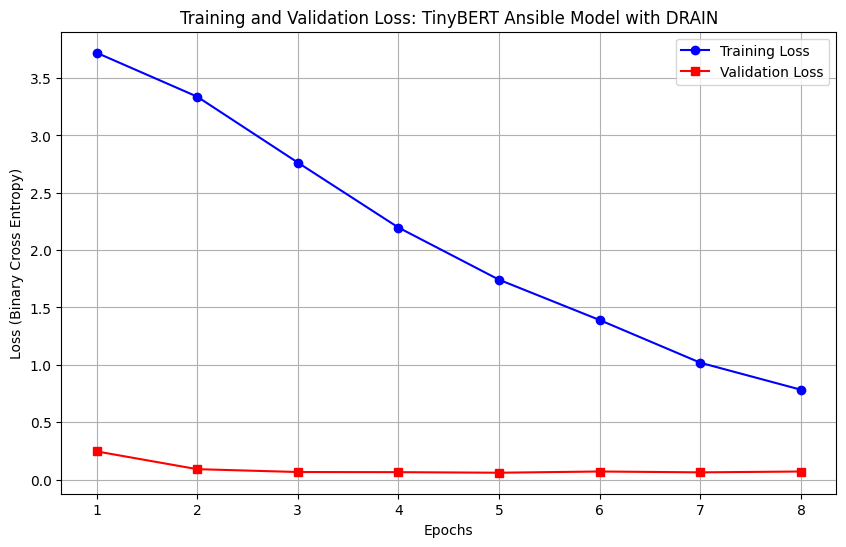

In [ ]:
import matplotlib.pyplot as plt

# Extract the logs
history = trainer.state.log_history

# Separate Training and Validation logs
train_loss = [log['loss'] for log in history if 'loss' in log]
val_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]
epochs = range(1, len(val_loss) + 1)

# Create the Plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss[:len(val_loss)], 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-s', label='Validation Loss')

plt.title('Training and Validation Loss: TinyBERT Ansible Model with DRAIN')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Cross Entropy)')
plt.legend()
plt.grid(True)

# Save to local Colab files and Google Drive
plt.savefig("loss_curve.png", dpi=300) # High-res for printing
if os.path.exists("/content/drive/MyDrive/BSc_Thesis_Model_v6_WITH_DRAIN_NEW"):
    plt.savefig("/content/drive/MyDrive/BSc_Thesis_Model_v6_WITH_DRAIN_NEW/train_val_plot.png", dpi=300)

plt.show()